In [ ]:
Part-of-Speech Tagging and Named Entity Recognition 

In [4]:
!pip install spacy nltk

     ---------------------------------------- 1.5/1.5 MB 98.0 kB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!python -m spacy download en_core_web_sm

     -------------------------------------- 12.8/12.8 MB 124.1 kB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# =============================
# NLP Analysis of NDTV News Article
# =============================

import spacy
import nltk
from nltk import Tree
from collections import Counter

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Paste the full text of the article here as a single string
article_text = """
Sara Hooker said the sheer scale of the summit, which saw more than 300,000 attendees, was a testament to its success. 
Sara Hooker also spoke warmly about India-US collaboration in emerging technologies.
As the AI Impact Summit 2026 drew to a close in the national capital, the event left behind not just sweeping policy conversations and ambitious declarations, but also an unexpectedly viral moment that captured the internet's imagination.
At the centre of it was Sara Hooker, computer scientist and CEO of US-based AI firm Adaption Labs, whose late-night room service order after missing a high-profile gala dinner became a talking point across India.
Hooker, who was in Delhi to attend the summit and participate in high-level discussions, shared on X that she had been invited to the gala dinner hosted alongside the Prime Minister.
However, a brief return to her hotel to change into formal attire turned into a misadventure familiar to many Delhi residents: gridlocked traffic.
By the time she made it back, the gala was over, leaving her with just one option at 11 pm, room service.
Her tweet about ordering a "home-style chicken curry" and potato curry quickly went viral, sparking amused reactions about Delhi traffic and Indian food culture.
Speaking to NDTV Senior Executive Editor Aditya Raj Kaul on the sidelines of the summit, Hooker took the viral moment in stride, calling it part of the essence of Delhi.
Delhi feels like it is shut down for the summit, but that's also part of the prestige of everyone being here.
"""

# =============================
# 1. Sentence Tokenization
# =============================
doc = nlp(article_text)
sentences = list(doc.sents)

print("------ Sentence Tokenization ------")
for i, sent in enumerate(sentences, 1):
    print(f"{i}. {sent.text}")

# =============================
# 2. POS Tagging
# =============================
print("\n------ POS Tagging ------")
for token in doc:
    print(f"{token.text}\t{token.pos_}")

# =============================
# 3. Named Entity Recognition
# =============================
print("\n------ Named Entities ------")
for ent in doc.ents:
    print(f"{ent.text}\t{ent.label_}")

# =============================
# 4. Most Common Noun Phrases
# =============================
noun_phrases = [chunk.text.lower() for chunk in doc.noun_chunks]
most_common_nps = Counter(noun_phrases).most_common(10)

print("\n------ Most Common Noun Phrases ------")
for phrase, freq in most_common_nps:
    print(f"{phrase} ({freq})")

# =============================
# 5. Parse Tree Visualization
# =============================

# Function to convert spacy parse to nltk Tree
def create_tree(token):
    if token.n_lefts + token.n_rights > 0:
        return Tree(token.orth_, [create_tree(child) for child in token.children])
    else:
        return token.orth_

print("\n------ Parse Trees for 5 Sentences ------")
for i, sent in enumerate(sentences[:5]):
    print(f"\nSentence {i+1}: {sent.text}")
    root = [token for token in sent if token.head == token][0]
    tree = create_tree(root)
    tree.pretty_print()

------ Sentence Tokenization ------
1. 
Sara Hooker said the sheer scale of the summit, which saw more than 300,000 attendees, was a testament to its success. 

2. Sara Hooker also spoke warmly about India-US collaboration in emerging technologies.

3. As the AI Impact Summit 2026 drew to a close in the national capital, the event left behind not just sweeping policy conversations and ambitious declarations, but also an unexpectedly viral moment that captured the internet's imagination.

4. At the centre of it was Sara Hooker, computer scientist and CEO of US-based AI firm Adaption Labs, whose late-night room service order after missing a high-profile gala dinner became a talking point across India.

5. Hooker, who was in Delhi to attend the summit and participate in high-level discussions, shared on X that she had been invited to the gala dinner hosted alongside the Prime Minister.

6. However, a brief return to her hotel to change into formal attire turned into a misadventure familia

In [ ]:
Text Classification using Machine Learning (25 Marks)

In [7]:
# Install (run only if not installed)
!pip install nltk scikit-learn matplotlib seaborn

     ---------------------------------------- 8.1/8.1 MB 149.8 kB/s eta 0:00:00
     ------------------------------------ 294.9/294.9 kB 157.0 kB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import reuters
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [9]:
nltk.download('reuters')
nltk.download('punkt')

[nltk_data] Downloading package reuters to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [10]:
documents = reuters.fileids()

X = []
y = []

for doc_id in documents:
    categories = reuters.categories(doc_id)
    if len(categories) == 1:  # single label only
        X.append(reuters.raw(doc_id))
        y.append(categories[0])

print("Total documents used:", len(X))

Total documents used: 9160


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
bow_vectorizer = CountVectorizer(stop_words='english', max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [13]:
model_bow = LogisticRegression(max_iter=1000)
model_bow.fit(X_train_bow, y_train)

y_pred_bow = model_bow.predict(X_test_bow)

In [14]:
accuracy_bow = accuracy_score(y_test, y_pred_bow)
precision_bow = precision_score(y_test, y_pred_bow, average='weighted')
recall_bow = recall_score(y_test, y_pred_bow, average='weighted')
f1_bow = f1_score(y_test, y_pred_bow, average='weighted')

print("Bag of Words Performance:")
print("Accuracy:", accuracy_bow)
print("Precision:", precision_bow)
print("Recall:", recall_bow)
print("F1 Score:", f1_bow)

Bag of Words Performance:
Accuracy: 0.9508733624454149
Precision: 0.9508586813111958
Recall: 0.9508733624454149
F1 Score: 0.9487501645859867


C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


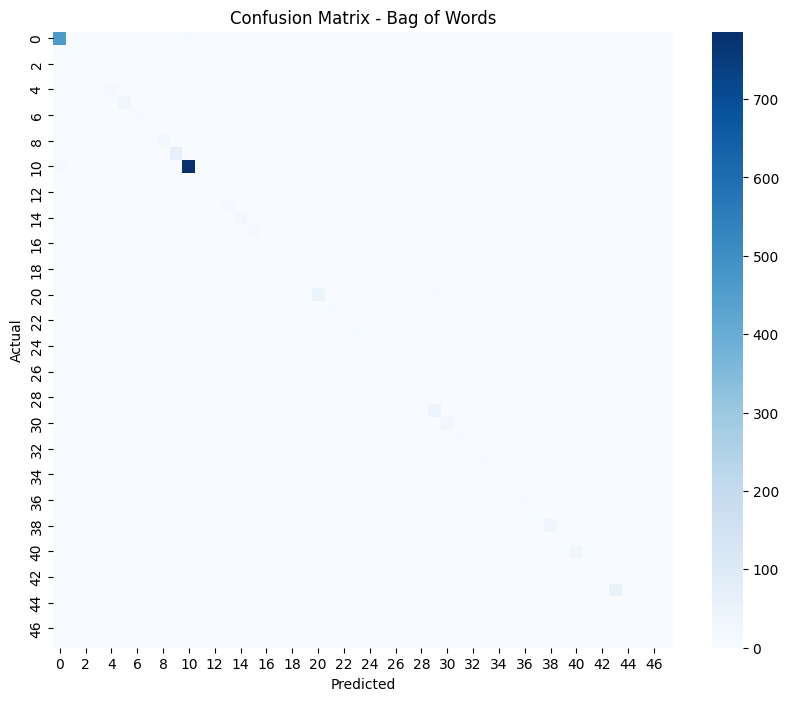

In [15]:
cm_bow = confusion_matrix(y_test, y_pred_bow)

plt.figure(figsize=(10,8))
sns.heatmap(cm_bow, cmap="Blues")
plt.title("Confusion Matrix - Bag of Words")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [18]:
model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

In [19]:
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)
precision_tfidf = precision_score(y_test, y_pred_tfidf, average='weighted')
recall_tfidf = recall_score(y_test, y_pred_tfidf, average='weighted')
f1_tfidf = f1_score(y_test, y_pred_tfidf, average='weighted')

print("TF-IDF Performance:")
print("Accuracy:", accuracy_tfidf)
print("Precision:", precision_tfidf)
print("Recall:", recall_tfidf)
print("F1 Score:", f1_tfidf)

TF-IDF Performance:
Accuracy: 0.9126637554585153
Precision: 0.8965458279205848
Recall: 0.9126637554585153
F1 Score: 0.8983356870497239


C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


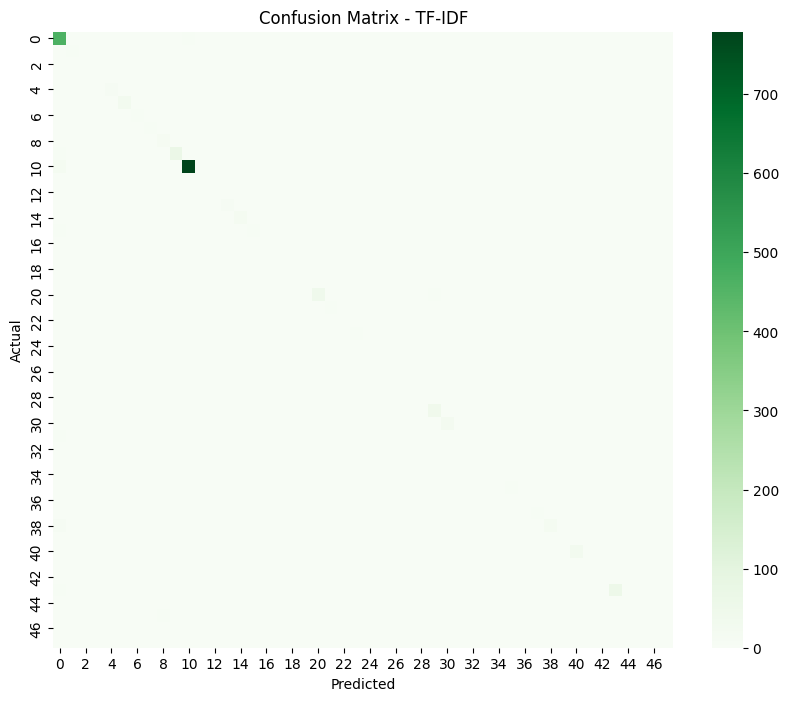

In [20]:
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(10,8))
sns.heatmap(cm_tfidf, cmap="Greens")
plt.title("Confusion Matrix - TF-IDF")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
🔹 3️⃣ Load Dataset (Amazon Ratings.csv)

In [23]:
file_path = r"C:\Users\ADMIN\Downloads\amazon_reviews.csv"

df = pd.read_csv(file_path)

df.head()

,Unnamed: 0,asin,helpful,overall,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,0528881469,"[0, 0]",5.0,We got this GPS for my husband who is an (OTR)...,"06 2, 2013",AO94DHGC771SJ,amazdnu,Gotta have GPS!,1.370131e+09
1,1,0528881469,"[12, 15]",1.0,"I'm a professional OTR truck driver, and I bou...","11 25, 2010",AMO214LNFCEI4,Amazon Customer,Very Disappointed,1.290643e+09
2,2,0528881469,"[43, 45]",3.0,"Well, what can I say. I've had this unit in m...","09 9, 2010",A3N7T0DY83Y4IG,C. A. Freeman,1st impression,1.283990e+09
3,3,0528881469,"[9, 10]",2.0,"Not going to write a long review, even thought...","11 24, 2010",A1H8PY3QHMQQA0,"Dave M. Shaw ""mack dave""","Great grafics, POOR GPS",1.290557e+09
4,4,0528881469,"[0, 0]",1.0,I've had mine for a year and here's what we go...,"09 29, 2011",A24EV6RXELQZ63,Wayne Smith,"Major issues, only excuses for support",1.317254e+09


In [32]:
df = df[['reviewText', 'overall']]
df = df.dropna()

# Take first 200 reviews
df = df.head(200)

df.shape

(181, 2)

In [33]:
df = df[df['overall'] != 3]

def label_sentiment(rating):
    if rating >= 4:
        return "Positive"
    else:
        return "Negative"

df['Sentiment'] = df['overall'].apply(label_sentiment)

df['Sentiment'].value_counts()

Sentiment
Positive    172
Negative      9
Name: count, dtype: int64

In [34]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['Clean_Text'] = df['reviewText'].apply(preprocess)

df[['reviewText','Clean_Text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,reviewText,Clean_Text
0,We got this GPS for my husband who is an (OTR)...,got gps husband otr road trucker impressed shi...
1,"I'm a professional OTR truck driver, and I bou...",professional otr truck driver bought tnd truck...
3,"Not going to write a long review, even thought...",going write long review even thought unit dese...
4,I've had mine for a year and here's what we go...,mine year got try route non truck route tellin...
5,I am using this with a Nook HD+. It works as d...,using nook hd work described hd picture samsun...


In [35]:
from sklearn.model_selection import train_test_split

X = df['Clean_Text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="Positive")
recall = recall_score(y_test, y_pred, pos_label="Positive")
f1 = f1_score(y_test, y_pred, pos_label="Positive")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.972972972972973
Precision: 0.972972972972973
Recall: 1.0
F1 Score: 0.9863013698630136


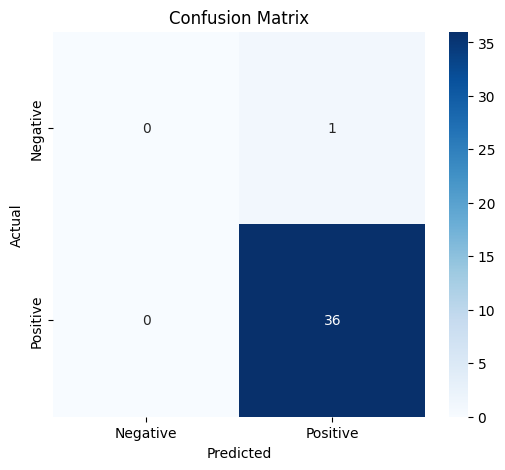

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
custom_reviews = [
    "This product is absolutely amazing and works perfectly",
    "Worst product I have ever bought",
    "It is okay but not worth the price",
    "Very happy with the purchase",
    "Completely useless and stopped working"
]

clean_custom = [preprocess(review) for review in custom_reviews]
vector_custom = vectorizer.transform(clean_custom)

predictions = model.predict(vector_custom)

for review, sentiment in zip(custom_reviews, predictions):
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("-"*50)

Review: This product is absolutely amazing and works perfectly
Predicted Sentiment: Positive
--------------------------------------------------
Review: Worst product I have ever bought
Predicted Sentiment: Positive
--------------------------------------------------
Review: It is okay but not worth the price
Predicted Sentiment: Positive
--------------------------------------------------
Review: Very happy with the purchase
Predicted Sentiment: Positive
--------------------------------------------------
Review: Completely useless and stopped working
Predicted Sentiment: Positive
--------------------------------------------------


In [41]:
!pip install nltk
import nltk
import random
import math
from collections import Counter, defaultdict
from nltk.util import ngrams
from nltk.corpus import gutenberg

nltk.download('gutenberg')
nltk.download('punkt')



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [42]:
# Load text
text = gutenberg.raw('austen-emma.txt')

# Tokenize
tokens = nltk.word_tokenize(text.lower())

# Remove punctuation tokens
tokens = [word for word in tokens if word.isalpha()]

print("Total Tokens:", len(tokens))


Total Tokens: 157110


In [43]:
unigram_counts = Counter(tokens)
total_unigrams = sum(unigram_counts.values())

def unigram_prob(word):
    return unigram_counts[word] / total_unigrams


In [44]:
bigram_counts = Counter(ngrams(tokens, 2))
unigram_counts = Counter(tokens)

def bigram_prob(w1, w2):
    return bigram_counts[(w1, w2)] / unigram_counts[w1] if unigram_counts[w1] > 0 else 0


In [45]:
trigram_counts = Counter(ngrams(tokens, 3))
bigram_counts = Counter(ngrams(tokens, 2))

def trigram_prob(w1, w2, w3):
    return trigram_counts[(w1, w2, w3)] / bigram_counts[(w1, w2)] if bigram_counts[(w1, w2)] > 0 else 0


In [46]:
sentence = "emma was happy"
sentence_tokens = nltk.word_tokenize(sentence.lower())


In [47]:
def sentence_prob_unigram(sentence_tokens):
    prob = 1
    for word in sentence_tokens:
        prob *= unigram_prob(word)
    return prob

print("Unigram Probability:", sentence_prob_unigram(sentence_tokens))


Unigram Probability: 6.535501076653638e-08


In [48]:
def sentence_prob_bigram(sentence_tokens):
    prob = 1
    for w1, w2 in ngrams(sentence_tokens, 2):
        prob *= bigram_prob(w1, w2)
    return prob

print("Bigram Probability:", sentence_prob_bigram(sentence_tokens))


Bigram Probability: 6.406025546453392e-05


In [49]:
def sentence_prob_trigram(sentence_tokens):
    prob = 1
    for w1, w2, w3 in ngrams(sentence_tokens, 3):
        prob *= trigram_prob(w1, w2, w3)
    return prob

print("Trigram Probability:", sentence_prob_trigram(sentence_tokens))


Trigram Probability: 0.0


In [50]:
def generate_text_bigram(start_word, length=15):
    current_word = start_word
    output = [current_word]

    for _ in range(length):
        candidates = [(w2, bigram_counts[(current_word, w2)]) 
                      for (w1, w2) in bigram_counts if w1 == current_word]

        if not candidates:
            break

        words, weights = zip(*candidates)
        current_word = random.choices(words, weights=weights)[0]
        output.append(current_word)

    return " ".join(output)

print(generate_text_bigram("emma", 20))


emma assisted with a respectable length as sufficiently before dinner engagement she is not once henry must spend in saying we


In [51]:
def perplexity_bigram(sentence_tokens):
    N = len(sentence_tokens)
    log_prob = 0
    
    for w1, w2 in ngrams(sentence_tokens, 2):
        prob = bigram_prob(w1, w2)
        if prob > 0:
            log_prob += math.log2(prob)
    
    return 2 ** (-log_prob / N)

print("Bigram Perplexity:", perplexity_bigram(sentence_tokens))


Bigram Perplexity: 24.992159157266112


In [52]:
def perplexity_trigram(sentence_tokens):
    N = len(sentence_tokens)
    log_prob = 0
    
    for w1, w2, w3 in ngrams(sentence_tokens, 3):
        prob = trigram_prob(w1, w2, w3)
        if prob > 0:
            log_prob += math.log2(prob)
    
    return 2 ** (-log_prob / N)

print("Trigram Perplexity:", perplexity_trigram(sentence_tokens))


Trigram Perplexity: 1.0


In [53]:
!pip install nltk gensim scikit-learn matplotlib
import nltk
import gensim
import matplotlib.pyplot as plt
import numpy as np

from nltk.corpus import brown
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

nltk.download('brown')



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!


True

In [54]:
# Load Brown corpus sentences
sentences = brown.sents()

# Convert to lowercase
sentences = [[word.lower() for word in sent] for sent in sentences]

print("Total Sentences:", len(sentences))


Total Sentences: 57340


In [55]:
from gensim.models import Word2Vec

# Train model
model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)

print("Vocabulary size:", len(model.wv))


Vocabulary size: 14221


In [56]:
similar_words = model.wv.most_similar("government", topn=10)

print("Top 10 similar words to 'government':")
for word, score in similar_words:
    print(word, "->", score)


Top 10 similar words to 'government':
union -> 0.9081405997276306
local -> 0.9059483408927917
federal -> 0.9000271558761597
service -> 0.8825179934501648
program -> 0.8798367381095886
power -> 0.8759312033653259
education -> 0.8705209493637085
assistance -> 0.8682191371917725
community -> 0.8666657209396362
development -> 0.8662065267562866


In [57]:
words = ["france", "germany", "italy", "banana"]

odd_word = model.wv.doesnt_match(words)

print("Odd word out:", odd_word)


Odd word out: germany


In [58]:
model.wv.most_similar(positive=["king", "woman"], negative=["man"])

[('richardson', 0.9331538677215576),
 ('followers', 0.9324118494987488),
 ('birthday', 0.9278194904327393),
 ('leo', 0.9272523522377014),
 ('41', 0.9262552857398987),
 ('formerly', 0.9238303899765015),
 ('incredibly', 0.9205496907234192),
 ('giants', 0.9193894863128662),
 ('judge', 0.9191372394561768),
 ('op.', 0.9187995791435242)]

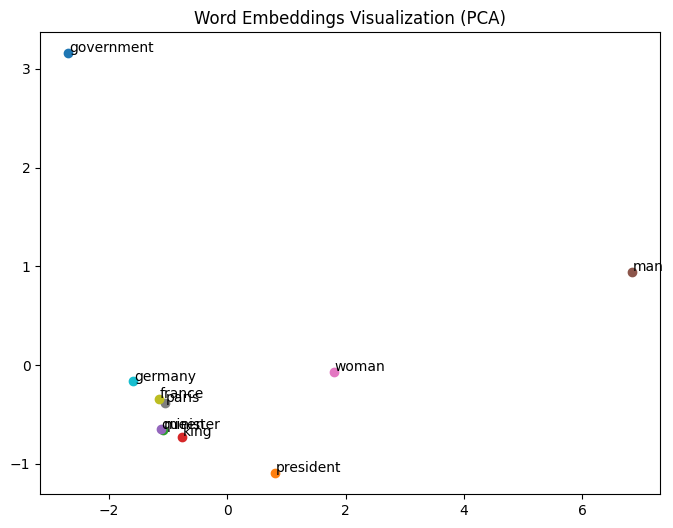

NameError: name '________________________________________' is not defined

In [59]:
words_to_visualize = ["government", "president", "minister", 
                      "king", "queen", "man", "woman",
                      "paris", "france", "germany"]

# Get vectors
vectors = np.array([model.wv[word] for word in words_to_visualize])

# Reduce dimensions
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(8,6))
for i, word in enumerate(words_to_visualize):
    x, y = reduced_vectors[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("Word Embeddings Visualization (PCA)")
plt.show()
________________________________________


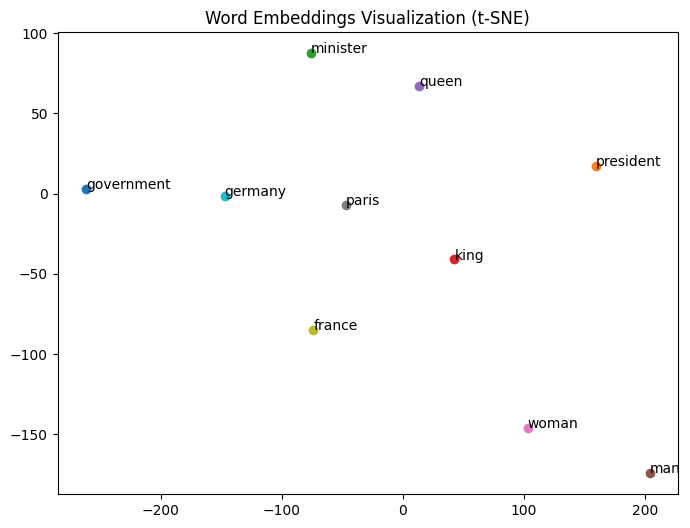

In [61]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
tsne_vectors = tsne.fit_transform(vectors)

plt.figure(figsize=(8,6))
for i, word in enumerate(words_to_visualize):
    x, y = tsne_vectors[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("Word Embeddings Visualization (t-SNE)")
plt.show()


In [62]:
!pip install nltk gensim scikit-learn pyLDAvis

     ---------------------------------------- 2.6/2.6 MB 415.5 kB/s eta 0:00:00
     ------------------------------------ 160.1/160.1 kB 309.6 kB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
import nltk
import re
import gensim
import numpy as np
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.datasets import fetch_20newsgroups
from gensim import corpora
from gensim.models import CoherenceModel
from gensim.models.ldamodel import LdaModel

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [64]:
# Load dataset
dataset = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))

documents = dataset.data

print("Total documents:", len(documents))


Total documents: 11314


In [65]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 3]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

processed_docs = [preprocess(doc) for doc in documents]

print("Sample processed document:")
print(processed_docs[0][:20])


Sample processed document:
['wondering', 'anyone', 'could', 'enlighten', 'door', 'sport', 'looked', 'late', 'early', 'called', 'bricklin', 'door', 'really', 'small', 'addition', 'front', 'bumper', 'separate', 'rest', 'body']


In [66]:
# Create dictionary
dictionary = corpora.Dictionary(processed_docs)

# Remove rare and very frequent words
dictionary.filter_extremes(no_below=15, no_above=0.5)

# Create Bag-of-Words corpus
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

print("Total unique tokens:", len(dictionary))


Total unique tokens: 5830


In [67]:
num_topics = 5

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    alpha='auto'
)

print("LDA Model trained successfully!")


LDA Model trained successfully!


In [68]:
for i in range(num_topics):
    print(f"\nTopic {i+1}:")
    words = lda_model.show_topic(i, topn=10)
    for word, prob in words:
        print(word, "->", round(prob, 4))



Topic 1:
drive -> 0.012
would -> 0.0092
card -> 0.0084
like -> 0.0079
problem -> 0.0075
system -> 0.0075
know -> 0.0067
work -> 0.0066
disk -> 0.0057
need -> 0.0057

Topic 2:
government -> 0.0083
state -> 0.007
armenian -> 0.0064
year -> 0.0056
space -> 0.0054
president -> 0.0051
national -> 0.0044
american -> 0.0043
public -> 0.0041
people -> 0.004

Topic 3:
file -> 0.0156
program -> 0.01
window -> 0.0097
image -> 0.0065
system -> 0.0064
available -> 0.0064
information -> 0.0062
also -> 0.0058
data -> 0.0056
version -> 0.0054

Topic 4:
would -> 0.012
people -> 0.0118
think -> 0.007
dont -> 0.0069
know -> 0.0056
right -> 0.0051
like -> 0.0051
believe -> 0.0049
even -> 0.0048
make -> 0.0048

Topic 5:
would -> 0.0094
dont -> 0.0093
year -> 0.0092
like -> 0.0083
game -> 0.0082
think -> 0.008
know -> 0.0077
time -> 0.0077
team -> 0.0071
well -> 0.0066


In [69]:
coherence_model = CoherenceModel(
    model=lda_model,
    texts=processed_docs,
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()

print("Coherence Score:", coherence_score)


Coherence Score: 0.5304964333481232


In [70]:
!pip install spacy
!python -m spacy download en_core_web_sm
import spacy
from spacy import displacy

nlp = spacy.load("en_core_web_sm")



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 12.8/12.8 MB 3.7 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [71]:
text = """
The government announced new policies to support small businesses.
Many companies welcomed the decision.
The president addressed the nation during a press conference.
Experts believe the reforms will improve the economy.
Citizens expressed their concerns about rising prices.
"""
doc = nlp(text)


In [72]:
for token in doc:
    print(token.text, "->", token.dep_, "->", token.head.text)



 -> dep -> The
The -> det -> government
government -> nsubj -> announced
announced -> ROOT -> announced
new -> amod -> policies
policies -> dobj -> announced
to -> aux -> support
support -> advcl -> announced
small -> amod -> businesses
businesses -> dobj -> support
. -> punct -> announced

 -> dep -> .
Many -> amod -> companies
companies -> nsubj -> welcomed
welcomed -> ROOT -> welcomed
the -> det -> decision
decision -> dobj -> welcomed
. -> punct -> welcomed

 -> dep -> .
The -> det -> president
president -> nsubj -> addressed
addressed -> ROOT -> addressed
the -> det -> nation
nation -> dobj -> addressed
during -> prep -> addressed
a -> det -> conference
press -> compound -> conference
conference -> pobj -> during
. -> punct -> addressed

 -> dep -> .
Experts -> nsubj -> believe
believe -> ROOT -> believe
the -> det -> reforms
reforms -> nsubj -> improve
will -> aux -> improve
improve -> ccomp -> believe
the -> det -> economy
economy -> dobj -> improve
. -> punct -> believe

 -> d

In [73]:
print("Subject-Verb Relationships:\n")

for token in doc:
    if token.dep_ in ("nsubj", "nsubjpass"):
        print("Subject:", token.text, 
              "| Verb:", token.head.text)


Subject-Verb Relationships:

Subject: government | Verb: announced
Subject: companies | Verb: welcomed
Subject: president | Verb: addressed
Subject: Experts | Verb: believe
Subject: reforms | Verb: improve
Subject: Citizens | Verb: expressed


In [74]:
print("\nObject Relationships:\n")

for token in doc:
    if token.dep_ in ("dobj", "pobj"):
        print("Object:", token.text, 
              "| Head:", token.head.text)



Object Relationships:

Object: policies | Head: announced
Object: businesses | Head: support
Object: decision | Head: welcomed
Object: nation | Head: addressed
Object: conference | Head: during
Object: economy | Head: improve
Object: concerns | Head: expressed
Object: prices | Head: about


In [75]:
print("\nNoun Chunks:\n")

for chunk in doc.noun_chunks:
    print(chunk.text)



Noun Chunks:


The government
new policies
small businesses
Many companies
the decision
The president
the nation
a press conference
Experts
the reforms
the economy
Citizens
their concerns
rising prices


In [76]:
displacy.render(doc, style="dep", jupyter=True)

In [77]:
file_path = r"C:\Users\Admin\Downloads\enron_spam_data.csv"

df = pd.read_csv(file_path)

df.head()


,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


In [78]:
df['text'] = df['Subject'].fillna('') + " " + df['Message'].fillna('')

In [79]:
df['label'] = df['Spam/Ham'].map({'spam':1, 'ham':0})
df['label'].value_counts()


label
1    17171
0    16545
Name: count, dtype: int64

In [80]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

df[['text','clean_text']].head()


,text,clean_text
0,christmas tree farm pictures,christmas tree farm picture
1,"vastar resources , inc . gary , production fro...",vastar resource inc gary production high islan...
2,calpine daily gas nomination - calpine daily g...,calpine daily gas nomination calpine daily gas...
3,re : issue fyi - see note below - already done...,issue fyi see note already done stella forward...
4,meter 7268 nov allocation fyi .\n- - - - - - -...,meter nov allocation fyi forwarded lauri allen...


In [81]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df['label']


In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [84]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)


In [86]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)


In [87]:
print("Naïve Bayes Performance:")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall:", recall_score(y_test, nb_pred))
print("F1 Score:", f1_score(y_test, nb_pred))


Naïve Bayes Performance:
Accuracy: 0.9811684460260973
Precision: 0.9757903731130732
Recall: 0.9878892733564014
F1 Score: 0.9818025505086688


In [88]:
print("SVM Performance:")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall:", recall_score(y_test, svm_pred))
print("F1 Score:", f1_score(y_test, svm_pred))


SVM Performance:
Accuracy: 0.9872479240806643
Precision: 0.9848050458715596
Recall: 0.990484429065744
F1 Score: 0.9876365727429557


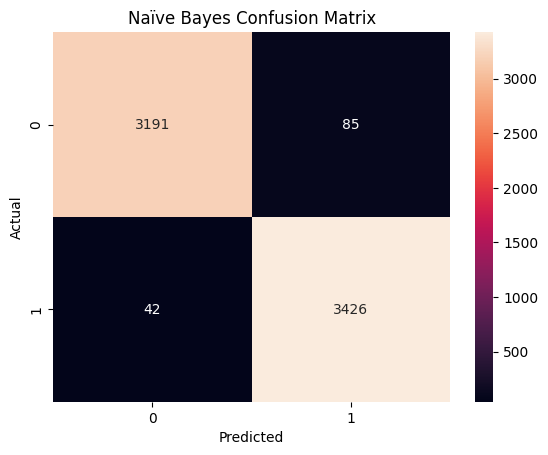

In [89]:
cm_nb = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Naïve Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


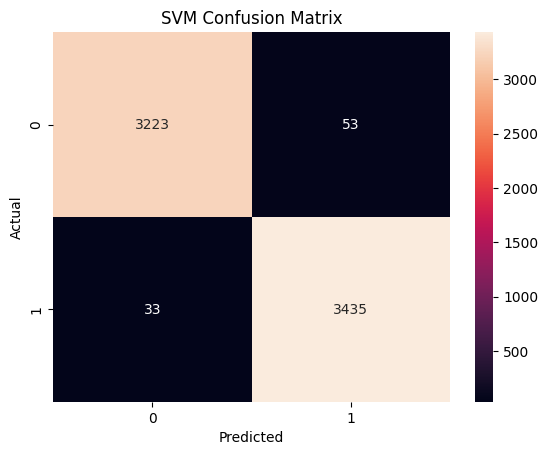

In [90]:
cm_svm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [91]:
!pip install spacy
!python -m spacy download en_core_web_sm



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 12.8/12.8 MB 5.1 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
("text", {"entities": [(start, end, "LABEL")]})

NameError: name 'start' is not defined

In [93]:
TRAIN_DATA = [
    ("Elon Musk founded SpaceX in California.",
     {"entities": [(0, 9, "PERSON"), (18, 24, "ORG"), (28, 38, "GPE")]}),

    ("Sundar Pichai is the CEO of Google.",
     {"entities": [(0, 13, "PERSON"), (28, 34, "ORG")]}),

    ("Microsoft was established in Washington.",
     {"entities": [(0, 9, "ORG"), (28, 38, "GPE")]}),

    ("Narendra Modi visited New York.",
     {"entities": [(0, 13, "PERSON"), (22, 30, "GPE")]}),

    ("Apple released the new iPhone in London.",
     {"entities": [(0, 5, "ORG"), (34, 40, "GPE")]}),

    ("Jeff Bezos started Amazon in Seattle.",
     {"entities": [(0, 10, "PERSON"), (19, 25, "ORG"), (29, 36, "GPE")]}),

    ("Tesla operates factories in Germany.",
     {"entities": [(0, 5, "ORG"), (29, 36, "GPE")]}),

    ("Barack Obama was born in Hawaii.",
     {"entities": [(0, 12, "PERSON"), (25, 31, "GPE")]}),

    ("Facebook headquarters are in California.",
     {"entities": [(0, 8, "ORG"), (28, 38, "GPE")]}),

    ("Bill Gates donated money in India.",
     {"entities": [(0, 10, "PERSON"), (27, 32, "GPE")]}),

    ("IBM partnered with NASA in Texas.",
     {"entities": [(0, 3, "ORG"), (18, 22, "ORG"), (26, 31, "GPE")]}),

    ("Ratan Tata leads Tata Group.",
     {"entities": [(0, 10, "PERSON"), (17, 27, "ORG")]}),

    ("The United Nations is based in New York.",
     {"entities": [(4, 18, "ORG"), (31, 39, "GPE")]}),

    ("Amazon opened a branch in Paris.",
     {"entities": [(0, 6, "ORG"), (25, 30, "GPE")]}),

    ("Tim Cook works at Apple.",
     {"entities": [(0, 8, "PERSON"), (18, 23, "ORG")]}),

    ("Google organized an event in Berlin.",
     {"entities": [(0, 6, "ORG"), (30, 36, "GPE")]}),

    ("Satya Nadella leads Microsoft.",
     {"entities": [(0, 14, "PERSON"), (21, 30, "ORG")]}),

    ("Elon Musk spoke in Chicago.",
     {"entities": [(0, 9, "PERSON"), (19, 26, "GPE")]}),

    ("Tesla launched a product in Tokyo.",
     {"entities": [(0, 5, "ORG"), (27, 32, "GPE")]}),

    ("Mark Zuckerberg founded Facebook.",
     {"entities": [(0, 15, "PERSON"), (24, 32, "ORG")]})
]


In [94]:
import spacy
from spacy.training.example import Example
import random

# Create blank English model
nlp = spacy.blank("en")

# Add NER pipeline
ner = nlp.add_pipe("ner")

# Add labels
for _, annotations in TRAIN_DATA:
    for ent in annotations["entities"]:
        ner.add_label(ent[2])

# Training
optimizer = nlp.begin_training()

for epoch in range(30):
    random.shuffle(TRAIN_DATA)
    losses = {}
    
    for text, annotations in TRAIN_DATA:
        doc = nlp.make_doc(text)
        example = Example.from_dict(doc, annotations)
        nlp.update([example], losses=losses)
    
    print(f"Epoch {epoch+1}, Losses: {losses}")


C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Microsoft was established in Washington." with entities "[(0, 9, 'ORG'), (28, 38, 'GPE')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Amazon opened a branch in Paris." with entities "[(0, 6, 'ORG'), (25, 30, 'GPE')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\spacy\training\iob_utils.py:149: UserWarning: [W030] Some

Epoch 1, Losses: {'ner': np.float32(72.370056)}
Epoch 2, Losses: {'ner': np.float32(38.925243)}
Epoch 3, Losses: {'ner': np.float32(21.685001)}
Epoch 4, Losses: {'ner': np.float32(18.432344)}
Epoch 5, Losses: {'ner': np.float32(5.2721095)}
Epoch 6, Losses: {'ner': np.float32(6.62794)}
Epoch 7, Losses: {'ner': np.float32(2.4115298)}
Epoch 8, Losses: {'ner': np.float32(2.6299508)}
Epoch 9, Losses: {'ner': np.float32(2.1012726)}
Epoch 10, Losses: {'ner': np.float32(0.04217106)}
Epoch 11, Losses: {'ner': np.float32(0.00011429691)}
Epoch 12, Losses: {'ner': np.float32(1.2004945e-05)}
Epoch 13, Losses: {'ner': np.float32(5.803951e-06)}
Epoch 14, Losses: {'ner': np.float32(2.2594616e-06)}
Epoch 15, Losses: {'ner': np.float32(1.2434579e-06)}
Epoch 16, Losses: {'ner': np.float32(1.1935638e-06)}
Epoch 17, Losses: {'ner': np.float32(4.4904004e-07)}
Epoch 18, Losses: {'ner': np.float32(2.4786315e-05)}
Epoch 19, Losses: {'ner': np.float32(3.815914e-07)}
Epoch 20, Losses: {'ner': np.float32(2.396457

In [95]:
test_text = "Elon Musk visited Microsoft in Germany."

doc = nlp(test_text)

for ent in doc.ents:
    print(ent.text, ent.label_)


Elon Musk PERSON
Microsoft ORG
Germany GPE


In [96]:
from spacy.scorer import Scorer

scorer = Scorer()

examples = []
for text, annotations in TRAIN_DATA:
    doc = nlp.make_doc(text)
    example = Example.from_dict(doc, annotations)
    pred_doc = nlp(text)
    example = Example(pred_doc, example.reference)
    examples.append(example)

scores = scorer.score(examples)

print("Precision:", scores["ents_p"])
print("Recall:", scores["ents_r"])
print("F1 Score:", scores["ents_f"])


Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [97]:
!pip install python-docx scikit-learn nltk pandas seaborn matplotlib

     -------------------------------------- 253.0/253.0 kB 3.1 MB/s eta 0:00:00
     ---------------------------------------- 4.0/4.0 MB 6.4 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
import os
import re
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from docx import Document
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [99]:
folder_path = r"C:\Users\Admin\Documents"

file_names = [
    "Impact of Extended Reality.docx",
    "Linear regression model_6717.docx",
    "Project Proposal.docx",
    "SoftwareRequirements.docx",
    "twitter api.docx"
]

def read_docx(file_path):
    doc = Document(file_path)
    return "\n".join([para.text for para in doc.paragraphs])

documents = []
doc_labels = []

for file in file_names:
    file_path = os.path.join(folder_path, file)
    text = read_docx(file_path)
    documents.append(text)
    doc_labels.append(file.replace(".docx", ""))

print("Loaded Documents:", len(documents))


Loaded Documents: 5


In [100]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

clean_docs = [preprocess(doc) for doc in documents]


In [101]:
vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(clean_docs)

cosine_sim_matrix = cosine_similarity(tfidf_matrix)

cosine_df = pd.DataFrame(cosine_sim_matrix,
                         index=doc_labels,
                         columns=doc_labels)

cosine_df


,Impact of Extended Reality,Linear regression model_6717,Project Proposal,SoftwareRequirements,twitter api
Impact of Extended Reality,1.000000,0.039107,0.048832,0.039888,0.007898
Linear regression model_6717,0.039107,1.000000,0.065498,0.019386,0.000000
Project Proposal,0.048832,0.065498,1.000000,0.047740,0.041028
SoftwareRequirements,0.039888,0.019386,0.047740,1.000000,0.000000
twitter api,0.007898,0.000000,0.041028,0.000000,1.000000


In [102]:
def jaccard_similarity(doc1, doc2):
    set1 = set(nltk.word_tokenize(doc1))
    set2 = set(nltk.word_tokenize(doc2))
    return len(set1.intersection(set2)) / len(set1.union(set2))

jaccard_matrix = np.zeros((len(clean_docs), len(clean_docs)))

for i in range(len(clean_docs)):
    for j in range(len(clean_docs)):
        jaccard_matrix[i][j] = jaccard_similarity(clean_docs[i], clean_docs[j])

jaccard_df = pd.DataFrame(jaccard_matrix,
                          index=doc_labels,
                          columns=doc_labels)

jaccard_df


,Impact of Extended Reality,Linear regression model_6717,Project Proposal,SoftwareRequirements,twitter api
Impact of Extended Reality,1.000000,0.056135,0.101319,0.051262,0.001732
Linear regression model_6717,0.056135,1.000000,0.076106,0.082569,0.000000
Project Proposal,0.101319,0.076106,1.000000,0.089005,0.002237
SoftwareRequirements,0.051262,0.082569,0.089005,1.000000,0.000000
twitter api,0.001732,0.000000,0.002237,0.000000,1.000000


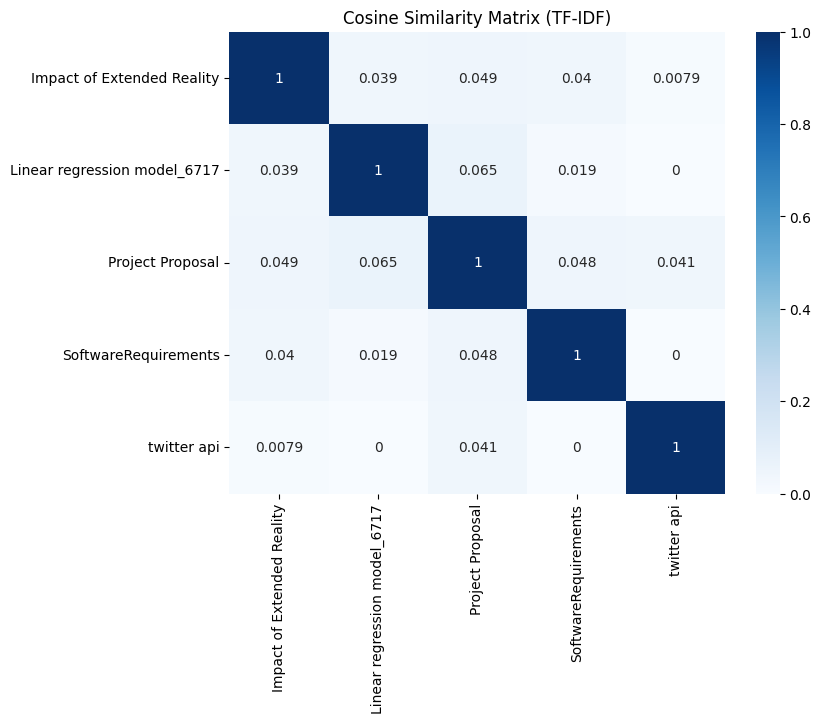

In [103]:
plt.figure(figsize=(8,6))
sns.heatmap(cosine_df, annot=True, cmap="Blues")
plt.title("Cosine Similarity Matrix (TF-IDF)")
plt.show()


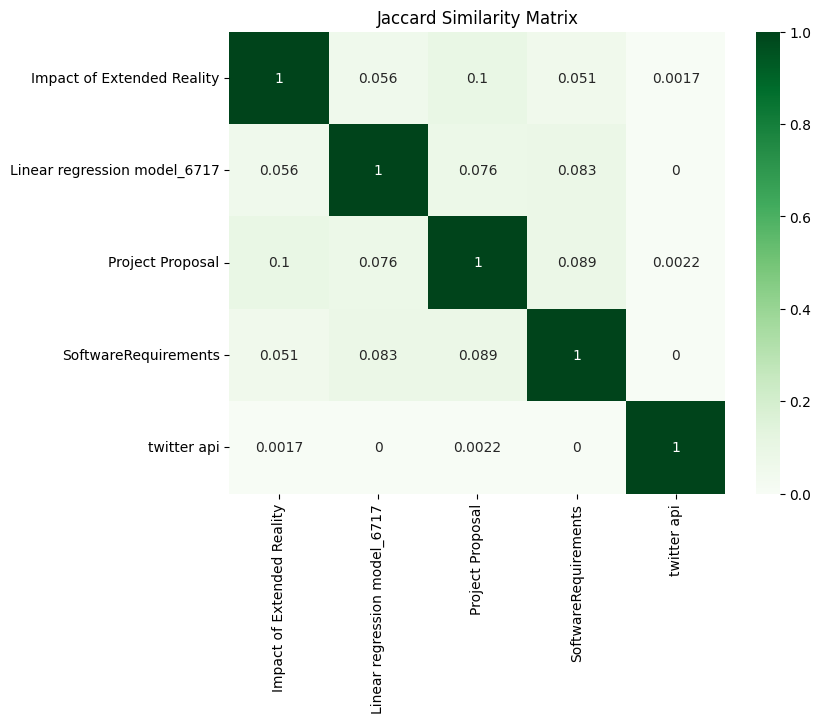

In [104]:
plt.figure(figsize=(8,6))
sns.heatmap(jaccard_df, annot=True, cmap="Greens")
plt.title("Jaccard Similarity Matrix")
plt.show()


In [105]:
np.fill_diagonal(cosine_sim_matrix, 0)

max_index = np.unravel_index(np.argmax(cosine_sim_matrix), cosine_sim_matrix.shape)

print("Most Similar Pair (Cosine):")
print(doc_labels[max_index[0]], "<--->", doc_labels[max_index[1]])
print("Similarity Score:", cosine_sim_matrix[max_index])


Most Similar Pair (Cosine):
Linear regression model_6717 <---> Project Proposal
Similarity Score: 0.06549827762503059
